# Flight Arrival Delay Prediction using Machine Learning

## Project Overview

This project predicts flight arrival delays using historical flight data. The workflow includes data cleaning, exploratory data analysis (EDA), feature engineering, model building, evaluation, and comparison using Linear Regression, Random Forest, and XGBoost.

## Import Required Libraries

Import the Python libraries required for data manipulation, visualization, preprocessing, and machine learning.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

## Load the Dataset

Read the flight dataset into a Pandas DataFrame for further analysis.

In [ ]:
try:
    df = pd.read_csv(
        "../data/raw/flight_data_2018_to_2022.csv",
        low_memory=False
    )
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Dataset not found. Please check the file path.")
except Exception as e:
    print("Error:", e)

Dataset loaded successfully.


## Initial Data Exploration

Inspect the dataset dimensions, data types, sample records, and overall structure before performing preprocessing.

In [3]:
df.shape

(563737, 120)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 563737 entries, 0 to 563736
Columns: 120 entries, Year to Unnamed: 119
dtypes: float64(72), int64(23), object(25)
memory usage: 516.1+ MB


In [5]:
df.head()

,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,IATA_Code_Marketing_Airline,...,Div5Airport,Div5AirportID,Div5AirportSeqID,Div5WheelsOn,Div5TotalGTime,Div5LongestGTime,Div5WheelsOff,Div5TailNum,Duplicate,Unnamed: 119
0,2022,1,1,6,4,2022-01-06,DL,DL,19790,DL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
1,2022,1,1,6,4,2022-01-06,DL,DL,19790,DL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
2,2022,1,1,6,4,2022-01-06,DL,DL,19790,DL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
3,2022,1,1,6,4,2022-01-06,DL,DL,19790,DL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
4,2022,1,1,6,4,2022-01-06,DL,DL,19790,DL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN


In [6]:
df.tail()

,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,IATA_Code_Marketing_Airline,...,Div5Airport,Div5AirportID,Div5AirportSeqID,Div5WheelsOn,Div5TotalGTime,Div5LongestGTime,Div5WheelsOff,Div5TailNum,Duplicate,Unnamed: 119
563732,2022,1,1,24,1,2022-01-24,UA,UA_CODESHARE,19977,UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
563733,2022,1,1,24,1,2022-01-24,UA,UA_CODESHARE,19977,UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
563734,2022,1,1,24,1,2022-01-24,UA,UA_CODESHARE,19977,UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
563735,2022,1,1,24,1,2022-01-24,UA,UA_CODESHARE,19977,UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
563736,2022,1,1,24,1,2022-01-24,UA,UA_CODESHARE,19977,UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN


In [7]:
df.describe()

,Year,Quarter,Month,DayofMonth,DayOfWeek,DOT_ID_Marketing_Airline,Flight_Number_Marketing_Airline,DOT_ID_Originally_Scheduled_Code_Share_Airline,Flight_Num_Originally_Scheduled_Code_Share_Airline,DOT_ID_Operating_Airline,...,Div4TailNum,Div5Airport,Div5AirportID,Div5AirportSeqID,Div5WheelsOn,Div5TotalGTime,Div5LongestGTime,Div5WheelsOff,Div5TailNum,Unnamed: 119
count,563737.0,563737.0,563737.0,563737.000000,563737.000000,563737.000000,563737.000000,17.0,17.000000,563737.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,2022.0,1.0,1.0,15.963577,4.044444,19831.807753,2680.255515,20304.0,4131.294118,20001.203114,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.0,0.0,0.0,8.982503,2.086369,271.869441,1803.194659,0.0,450.516060,376.353237,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,2022.0,1.0,1.0,1.000000,1.000000,19393.000000,1.000000,20304.0,3714.000000,19393.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,2022.0,1.0,1.0,8.000000,2.000000,19790.000000,1153.000000,20304.0,3855.000000,19790.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,2022.0,1.0,1.0,16.000000,4.000000,19805.000000,2314.000000,20304.0,3975.000000,19977.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,2022.0,1.0,1.0,24.000000,6.000000,19977.000000,4187.000000,20304.0,4138.000000,20378.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,2022.0,1.0,1.0,31.000000,7.000000,20436.000000,8816.000000,20304.0,5622.000000,20500.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data Cleaning

Remove unnecessary columns, handle missing values, and retain only features required for prediction.

In [8]:
df.columns = df.columns.str.strip()
df.columns

Index(['Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek', 'FlightDate',
       'Marketing_Airline_Network', 'Operated_or_Branded_Code_Share_Partners',
       'DOT_ID_Marketing_Airline', 'IATA_Code_Marketing_Airline',
       ...
       'Div5Airport', 'Div5AirportID', 'Div5AirportSeqID', 'Div5WheelsOn',
       'Div5TotalGTime', 'Div5LongestGTime', 'Div5WheelsOff', 'Div5TailNum',
       'Duplicate', 'Unnamed: 119'],
      dtype='object', length=120)

### Missing Value Analysis

Identify missing values and remove rows where the target variable is unavailable.

In [9]:
df.isnull().sum()

Year                     0
Quarter                  0
Month                    0
DayofMonth               0
DayOfWeek                0
                     ...  
Div5LongestGTime    563737
Div5WheelsOff       563737
Div5TailNum         563737
Duplicate                0
Unnamed: 119        563737
Length: 120, dtype: int64

## Feature Selection

Selected only the relevant features that are available before departure to avoid data leakage during prediction.

In [10]:
selected_features = [
    # Date features
    'Year',
    'Quarter',
    'Month',
    'DayofMonth',
    'DayOfWeek',
    # Airline features
    'Marketing_Airline_Network',
    'Operating_Airline',
    # Route features
    'Origin',
    'OriginState',
    'Dest',
    'DestState',
    # Scheduled Time Features
    'CRSDepTime',
    'CRSArrTime',
    'CRSElapsedTime',
    # Distance features
    'Distance',
    'DistanceGroup',

    # Target column 
    'ArrDelay'
]

existing_features = [col for col in selected_features if col in df.columns]

missing_features = [col for col in selected_features if col not in df.columns]

print("Missing columns:", missing_features)

df = df[existing_features]


Missing columns: []


## Feature Engineering

Create new features from the existing data to improve th predictive performace of the machine learning models.

In [11]:
df['DepHour'] = df['CRSDepTime'] // 100
df['ArrHour'] = df['CRSArrTime'] // 100

In [12]:
print(df.columns.tolist())

['Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek', 'Marketing_Airline_Network', 'Operating_Airline', 'Origin', 'OriginState', 'Dest', 'DestState', 'CRSDepTime', 'CRSArrTime', 'CRSElapsedTime', 'Distance', 'DistanceGroup', 'ArrDelay', 'DepHour', 'ArrHour']


## Exploratory Data Analysis

Perform exploratory analysis to understand the characteristics of the datase and identify factors influencing flight delays.

In [13]:
# missing values
df.isnull().sum().sort_values(ascending=False)

ArrDelay                     36843
Quarter                          0
Year                             0
Month                            0
DayofMonth                       0
Marketing_Airline_Network        0
DayOfWeek                        0
Origin                           0
OriginState                      0
Dest                             0
Operating_Airline                0
DestState                        0
CRSDepTime                       0
CRSElapsedTime                   0
CRSArrTime                       0
Distance                         0
DistanceGroup                    0
DepHour                          0
ArrHour                          0
dtype: int64

### Distribution of Arrival Delay

Visualize the distribution of arrival delays to understand the spread, skewness and presence of extreme values

In [14]:
df = df.dropna(subset=['ArrDelay'])

print(df.shape)
print(df['ArrDelay'].isnull().sum())

(526894, 19)
0


In [15]:
df['ArrDelay'].describe()

count    526894.000000
mean          4.221933
std          53.044248
min        -100.000000
25%         -17.000000
50%          -8.000000
75%           7.000000
max        2536.000000
Name: ArrDelay, dtype: float64

In [16]:
df['ArrDelay'].sort_values(ascending=False).head(20)

329338    2536.0
348208    2486.0
327175    2098.0
360120    2080.0
331485    1808.0
371797    1768.0
431260    1716.0
334008    1686.0
362053    1666.0
361823    1655.0
418017    1654.0
363887    1620.0
368079    1614.0
444489    1607.0
322826    1607.0
333992    1598.0
321883    1596.0
325578    1592.0
307423    1583.0
318757    1541.0
Name: ArrDelay, dtype: float64

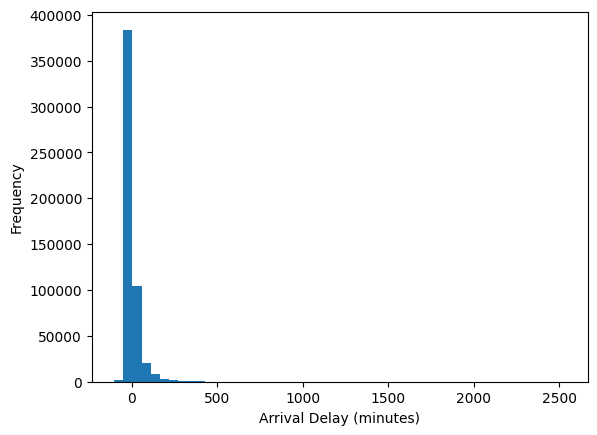

In [17]:
import matplotlib.pyplot as plt

plt.hist(df['ArrDelay'], bins=50)
plt.xlabel('Arrival Delay (minutes)')
plt.ylabel('Frequency')
plt.show()

### Average Arrival Delay by Airline

Analyze the average arrival delay for each airline to identify performnce differences.

In [18]:
df.groupby('Operating_Airline')['ArrDelay'].mean().sort_values()

Operating_Airline
MQ    -1.326464
AA    -1.075832
DL    -0.228486
WN     1.050331
9E     2.031073
YX     3.303216
UA     4.756270
AS     5.233294
HA     6.884220
PT     7.214458
OO     7.928475
C5     8.373430
NK     8.520168
ZW     9.850522
OH    10.698828
F9    10.955163
QX    10.964571
YV    11.159476
G4    12.243135
G7    13.448443
B6    18.721082
Name: ArrDelay, dtype: float64

In [19]:
df.groupby('Month')['ArrDelay'].mean()

Month
1    4.221933
Name: ArrDelay, dtype: float64

In [20]:
df.groupby('DayOfWeek')['ArrDelay'].mean()

DayOfWeek
1     5.773490
2    -0.762542
3    -2.123171
4     1.193400
5     6.465922
6     5.734183
7    10.912502
Name: ArrDelay, dtype: float64

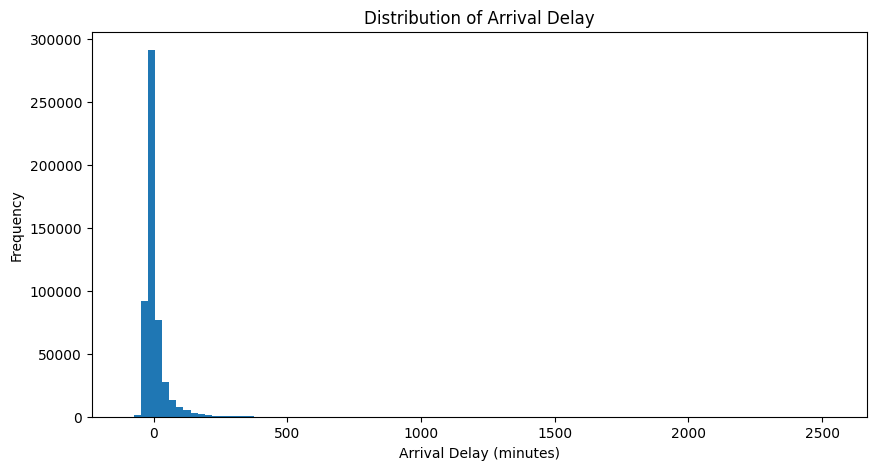

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(df['ArrDelay'], bins=100)
plt.xlabel("Arrival Delay (minutes)")
plt.ylabel("Frequency")
plt.title("Distribution of Arrival Delay")
plt.show()

In [22]:
df['ArrDelay'] = df['ArrDelay'].clip(-100, 300)

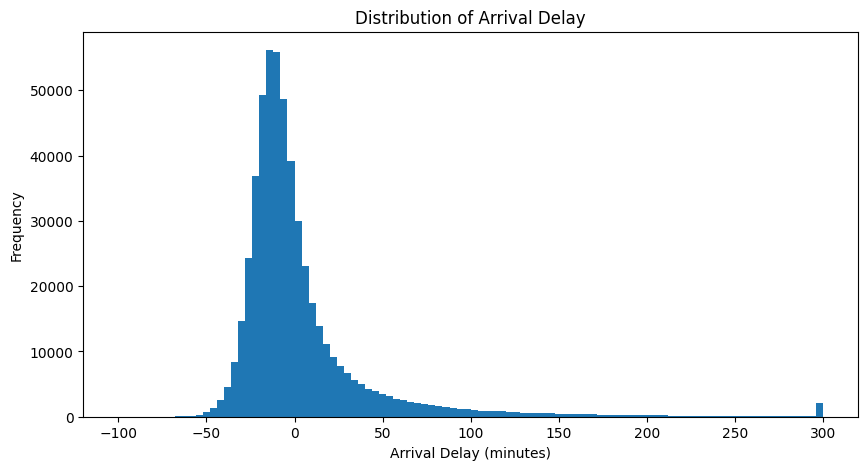

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(df['ArrDelay'], bins=100)
plt.xlabel("Arrival Delay (minutes)")
plt.ylabel("Frequency")
plt.title("Distribution of Arrival Delay")
plt.show()

In [24]:
# which airlines, months, and airports contribute most to delays
df.groupby('Operating_Airline')['ArrDelay'].mean().sort_values()

Operating_Airline
AA    -2.688835
MQ    -1.702889
DL    -1.065928
9E     0.693613
WN     1.029551
YX     2.937942
UA     3.933464
AS     5.078992
PT     5.686531
OO     6.246321
HA     6.681738
C5     6.980364
NK     7.774877
ZW     8.404470
YV     8.780343
OH     9.280911
F9    10.139213
QX    10.882468
G4    11.908966
G7    12.388678
B6    17.165173
Name: ArrDelay, dtype: float64

In [25]:
df.groupby('Month')['ArrDelay'].mean()

Month
1    3.30527
Name: ArrDelay, dtype: float64

In [26]:
df.groupby('DayOfWeek')['ArrDelay'].mean()

DayOfWeek
1    4.833152
2   -1.350463
3   -2.810226
4    0.407996
5    5.489966
6    4.577377
7    9.722916
Name: ArrDelay, dtype: float64

In [27]:
df.groupby('Origin')['ArrDelay'].mean().sort_values(ascending=False).head(20)

Origin
PPG    61.500000
DLG    48.200000
ART    35.805556
ATY    32.500000
TWF    31.193548
CNY    29.000000
PQI    28.977778
PSM    28.222222
APN    27.931818
GCC    27.187500
COU    25.345794
EYW    25.310576
ESC    24.145455
RIW    23.387755
SWF    23.070175
MQT    22.525253
IAG    22.137931
JMS    21.777778
ASE    20.637405
EAT    20.396226
Name: ArrDelay, dtype: float64

In [28]:
# Delay by airline
airline_delay = (
    df.groupby('Operating_Airline')['ArrDelay']
      .mean()
      .sort_values(ascending=False)
)

print(airline_delay)

Operating_Airline
B6    17.165173
G7    12.388678
G4    11.908966
QX    10.882468
F9    10.139213
OH     9.280911
YV     8.780343
ZW     8.404470
NK     7.774877
C5     6.980364
HA     6.681738
OO     6.246321
PT     5.686531
AS     5.078992
UA     3.933464
YX     2.937942
WN     1.029551
9E     0.693613
DL    -1.065928
MQ    -1.702889
AA    -2.688835
Name: ArrDelay, dtype: float64


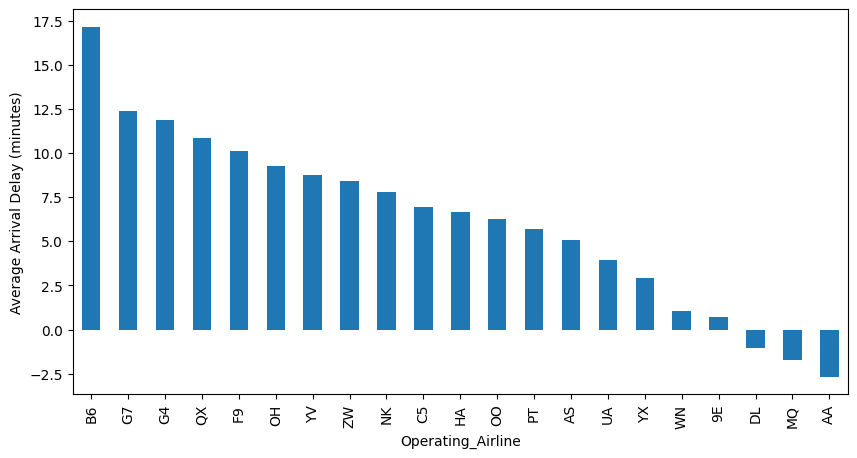

In [29]:
import matplotlib.pyplot as plt

airline_delay.plot(kind='bar', figsize=(10,5))
plt.ylabel("Average Arrival Delay (minutes)")
plt.show()

### Average Arrival Delay by Departure Hour

Study the relationship between scheduled departure hour and average arrival delay.

In [30]:
hour_delay = df.groupby('DepHour')['ArrDelay'].mean()

print(hour_delay)

DepHour
0      7.227058
1      3.672535
2     16.176871
3      3.775510
4     27.612903
5     -1.846652
6     -1.392215
7     -0.527905
8      0.080869
9      0.740777
10     1.182474
11     2.273459
12     2.533577
13     4.194712
14     4.065201
15     5.650795
16     5.435251
17     6.691063
18     5.820926
19     7.253754
20     6.818442
21     7.764063
22     5.307880
23     6.106901
Name: ArrDelay, dtype: float64


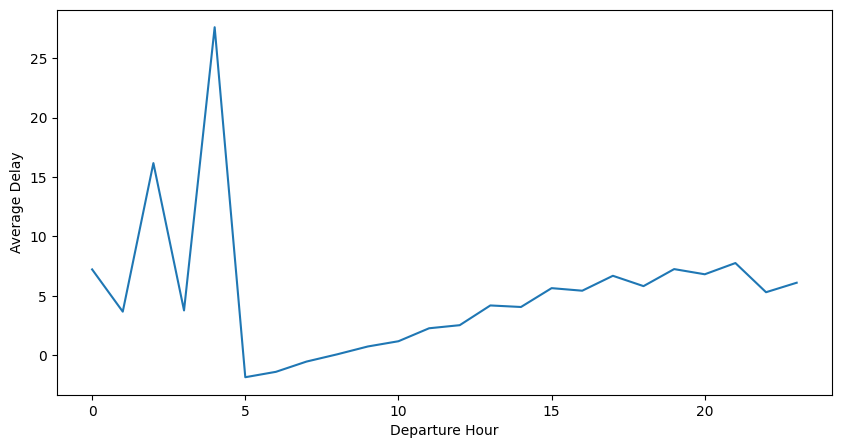

In [31]:
hour_delay.plot(figsize=(10,5))
plt.xlabel("Departure Hour")
plt.ylabel("Average Delay")
plt.show()

### Average Arrival Delay by Day of Week

Analyze how arrival delays vary across different days of the week.

In [32]:
# delay by DOW
dow_delay = df.groupby('DayOfWeek')['ArrDelay'].mean()

print(dow_delay)

DayOfWeek
1    4.833152
2   -1.350463
3   -2.810226
4    0.407996
5    5.489966
6    4.577377
7    9.722916
Name: ArrDelay, dtype: float64


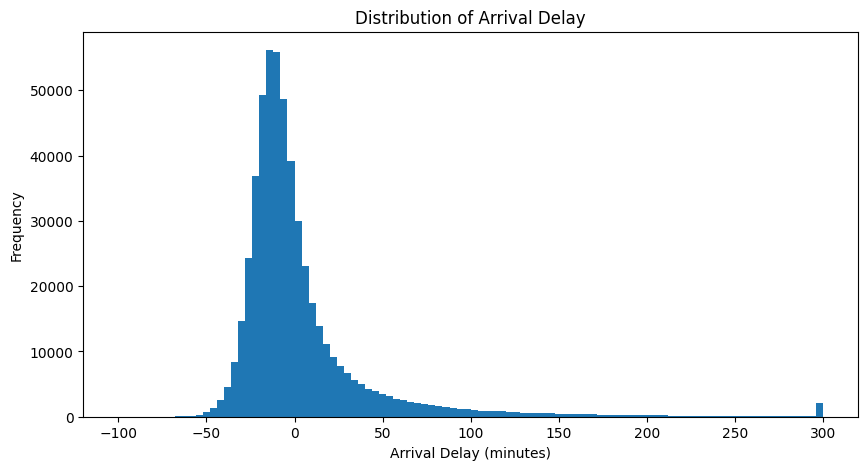

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(df['ArrDelay'], bins=100)
plt.xlabel('Arrival Delay (minutes)')
plt.ylabel('Frequency')
plt.title('Distribution of Arrival Delay')
plt.show()

In [34]:
# converting the scheduled time
df['DepHour'] = df['CRSDepTime'] // 100
df['ArrHour'] = df['CRSArrTime'] // 100

In [35]:
print(df.select_dtypes(include='object').columns)

Index(['Marketing_Airline_Network', 'Operating_Airline', 'Origin',
       'OriginState', 'Dest', 'DestState'],
      dtype='object')


### Correlation Analysis

Examine the relationships among numerical features using a correlation matrix.

In [36]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

corr = numeric_df.corr()

print(corr['ArrDelay'].sort_values(ascending=False))

ArrDelay          1.000000
CRSDepTime        0.065643
DepHour           0.065393
DayOfWeek         0.057418
CRSArrTime        0.049384
ArrHour           0.049271
Distance         -0.018723
DistanceGroup    -0.019340
CRSElapsedTime   -0.029851
DayofMonth       -0.154292
Year                   NaN
Quarter                NaN
Month                  NaN
Name: ArrDelay, dtype: float64


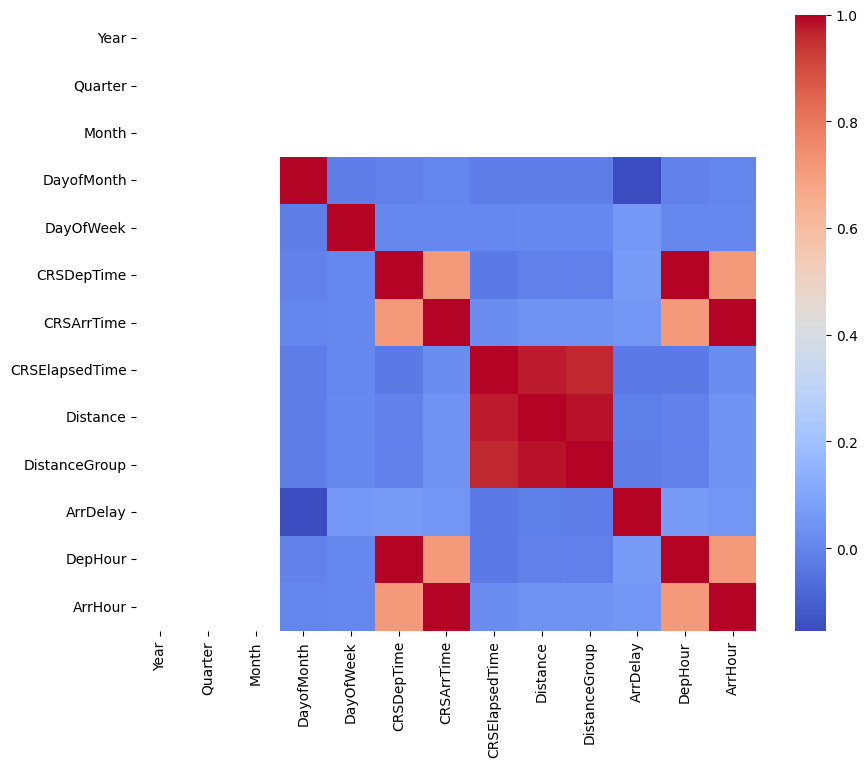

In [37]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm')
plt.show()

## Data Preprocessing

Convert categorical variables into numerical format using One-Hot Encoding to prepare the dataset for machine learning.

In [38]:
df = pd.get_dummies(
    df,
    columns=[
        'Marketing_Airline_Network',
        'Operating_Airline',
        'Origin',
        'OriginState',
        'Dest',
        'DestState'
    ],
    drop_first=True
)

## Train-Test Split

Split the dataset into training and testing sets to evaluate model performance on unseen data.

In [39]:
from sklearn.model_selection import train_test_split

X = df.drop('ArrDelay', axis=1)
y = df['ArrDelay']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

results = []

## Model 1: Linear Regression

Train a Linear Regression model as the baseline for comparison with more advanced machine learning models.

In [40]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

lr_preds = model.predict(X_test)

In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr_mae = mean_absolute_error(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_r2 = r2_score(y_test, lr_preds)

print("MAE :", mean_absolute_error(y_test, lr_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_preds)))
print("R2  :", r2_score(y_test, lr_preds))

MAE : 23.633117911507885
RMSE: 40.002999568283606
R2  : 0.06317172821297878


In [43]:
results.append({
    "Model": "Linear Regression",
    "MAE": lr_mae,
    "RMSE": lr_rmse,
    "R² Score": lr_r2
})

## Model 2: Random Forest Regressor

Train a Random Forest Regressor to capture nonlinear relationships between the features and arrival delay.

In [44]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

import time

start = time.time()

rf.fit(X_train, y_train)

end = time.time()

print(f"Training Time: {end - start:.2f} seconds")

rf_preds = rf.predict(X_test)

Training Time: 1947.43 seconds


In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

print("MAE :", mean_absolute_error(y_test, rf_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_preds)))
print("R2  :", r2_score(y_test, rf_preds))

MAE : 21.6045696960495
RMSE: 38.865232257608206
R2  : 0.11570451373720425


In [46]:
results.append({
    "Model": "Random Forest",
    "MAE": rf_mae,
    "RMSE": rf_rmse,
    "R² Score": rf_r2
})

## Model 3: XGBoost Regressor

Train an XGBoost Regressor, a powerful gradient boosting algorithm, for improved predictive performance.

In [47]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_preds = xgb.predict(X_test)

In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

xgb_mae = mean_absolute_error(y_test, xgb_preds)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_r2 = r2_score(y_test, xgb_preds)

print("MAE :", mean_absolute_error(y_test, xgb_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, xgb_preds)))
print("R2  :", r2_score(y_test, xgb_preds))

MAE : 21.90000085347447
RMSE: 37.99234546483157
R2  : 0.15497981173054864


In [49]:
results.append({
    "Model": "XGBoost",
    "MAE": xgb_mae,
    "RMSE": xgb_rmse,
    "R² Score": xgb_r2
})

## Model Comparison

Compare the performance of all models using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.

In [50]:
results_df = pd.DataFrame(results)

results_df = results_df.round({
    "MAE": 2,
    "RMSE": 2,
    "R² Score": 3
})

results_df

,Model,MAE,RMSE,R² Score
0,Linear Regression,23.63,40.00,0.063
1,Random Forest,21.60,38.87,0.116
2,XGBoost,21.90,37.99,0.155


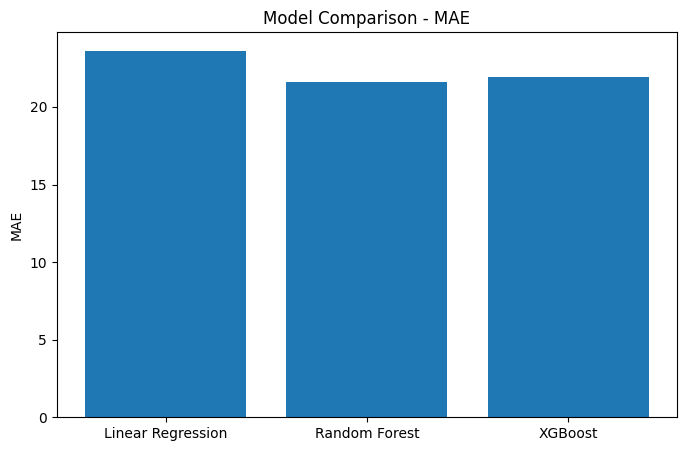

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["MAE"])
plt.title("Model Comparison - MAE")
plt.ylabel("MAE")
plt.show()

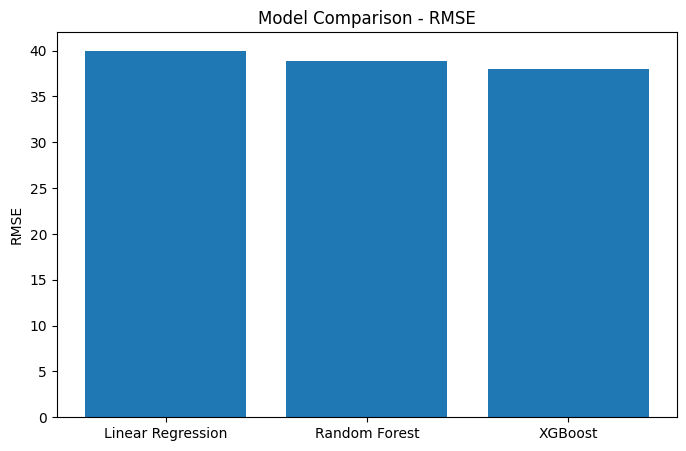

In [52]:
plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.title("Model Comparison - RMSE")
plt.ylabel("RMSE")
plt.show()

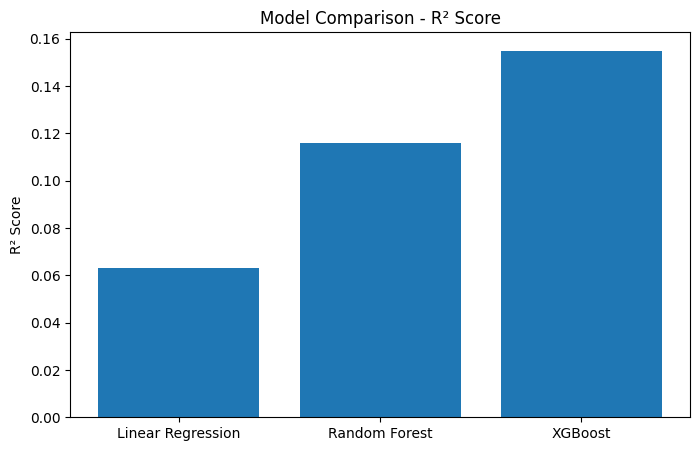

In [53]:
plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["R² Score"])
plt.title("Model Comparison - R² Score")
plt.ylabel("R² Score")
plt.show()

I evaluated Linear Regression, Random Forest, and XGBoost. XGBoost achieved the best overall performance with the highest R² score (0.155) and the lowest RMSE (37.99). Although Random Forest achieved a slightly lower MAE, the difference was less than one minute, while XGBoost explained substantially more variance in flight delays. Therefore, I selected XGBoost as the final model.


## Feature Importance

Identify the most influential features contributing to flight arrival delay prediction.

In [54]:
importance = pd.Series(
    xgb.feature_importances_,
    index=X_train.columns
)

top_features = importance.sort_values(
    ascending=False
).head(20)

print(top_features)

Operating_Airline_AA            0.021351
OriginState_CO                  0.018501
Marketing_Airline_Network_WN    0.017366
Marketing_Airline_Network_B6    0.017121
Dest_ORD                        0.015862
OriginState_NJ                  0.014933
DestState_CA                    0.014460
Operating_Airline_DL            0.013753
Origin_DEN                      0.013442
Origin_SLC                      0.013380
Marketing_Airline_Network_HA    0.012976
DestState_TX                    0.011833
Operating_Airline_MQ            0.011435
DayofMonth                      0.010623
OriginState_VA                  0.010583
Dest_DFW                        0.009909
Marketing_Airline_Network_DL    0.009804
OriginState_MN                  0.009386
Origin_ATL                      0.009178
DestState_FL                    0.008565
dtype: float32


<Axes: >

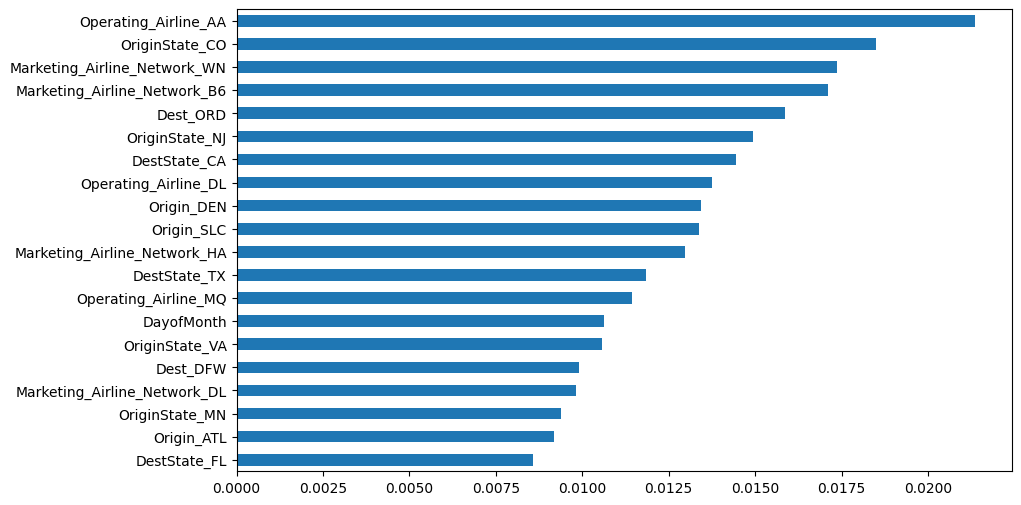

In [55]:
top_features.sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

## Model Evaluation

### Actual vs Predicted Values

Compare the predicted arrival delays with the actual values to evaluate model performance visually.

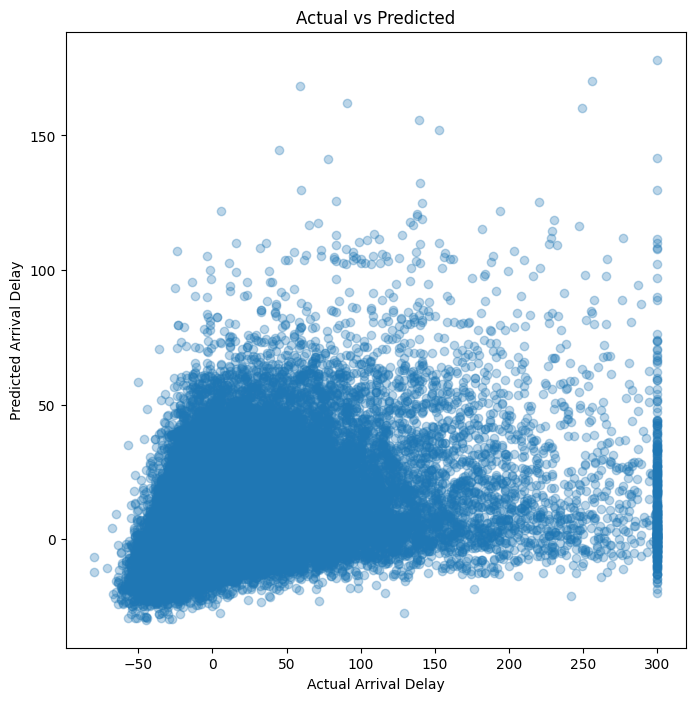

In [56]:
plt.figure(figsize=(8,8))
plt.scatter(y_test, xgb_preds, alpha=0.3)
plt.xlabel("Actual Arrival Delay")
plt.ylabel("Predicted Arrival Delay")
plt.title("Actual vs Predicted")
plt.show()

In [57]:
preds = xgb.predict(X_test)

errors = y_test - preds

errors.describe()

count    105379.000000
mean         -0.229540
std          37.991832
min        -130.886833
25%         -18.231956
50%          -7.986718
75%           4.731598
max         319.929968
Name: ArrDelay, dtype: float64

### Residual Analysis

Analyze the prediction errors (residuals) to identify patterns and evaluate the model's prediction quality.

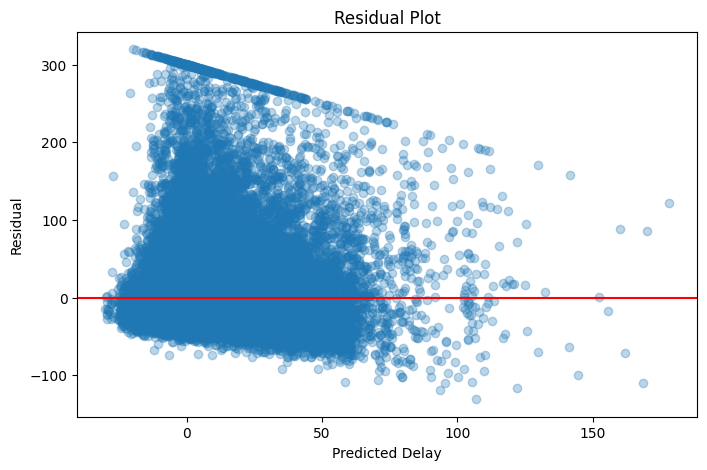

In [58]:
residuals = y_test - xgb_preds

plt.figure(figsize=(8,5))
plt.scatter(xgb_preds, residuals, alpha=0.3)
plt.axhline(0, color='red')
plt.xlabel("Predicted Delay")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

## Save the Trained Model

Save the best-performing model for future predictions and deployment.

In [59]:
import joblib

try:
    joblib.dump(xgb, "flight_delay_xgboost.pkl")
    print("Model saved successfully.")
except Exception as e:
    print(e)

Model saved successfully.


## Load the Saved Model

Load the saved model to verify that it has been stored correctly and can be reused.

In [60]:
try:
    model = joblib.load("flight_delay_xgboost.pkl")
    print("Model loaded successfully.")
except FileNotFoundError:
    print("Saved model not found.")
except Exception as e:
    print(e)

Model loaded successfully.


# Conclusion

This project successfully developed and evaluated multiple machine learning models for predicting flight arrival delays. Among the models tested, XGBoost achieved the best overall performance. The results demonstrate that pre-flight information such as airline, route, scheduled departure time, and flight distance can provide useful insights into arrival delays. Future improvements could include incorporating weather conditions, airport congestion, and previous flight delays to enhance prediction accuracy.